In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
df = pd.read_excel('/content/drive/MyDrive/hotel_bookings.xlsx')
# Fill missing values with 0
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)
# Outlier Treatment: Average Daily Rate (ADR)
# Removing negative rates and extreme outliers above the 99.9th percentile
q_high = df['adr'].quantile(0.999)
df = df[(df['adr'] >= 0) & (df['adr'] < q_high)]
# Feature Engineering: Engineering the 'total_stay' metric
# Combining weekend and weekday nights to get total stay duration
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
print(f"Data pipeline successfully executed. Shape: {df.shape}")
# Save the rigorously cleaned file for the upcoming dashboard
output_path = r"C:\Users\alaem\Downloads\churn-hotel-infotact\clean_data\week1\cleaned_hotel_bookings.csv"
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved at: {output_path}\n")

Data pipeline successfully executed. Shape: (119269, 33)
Cleaned dataset saved at: C:\Users\alaem\Downloads\churn-hotel-infotact\clean_data\week1\cleaned_hotel_bookings.csv



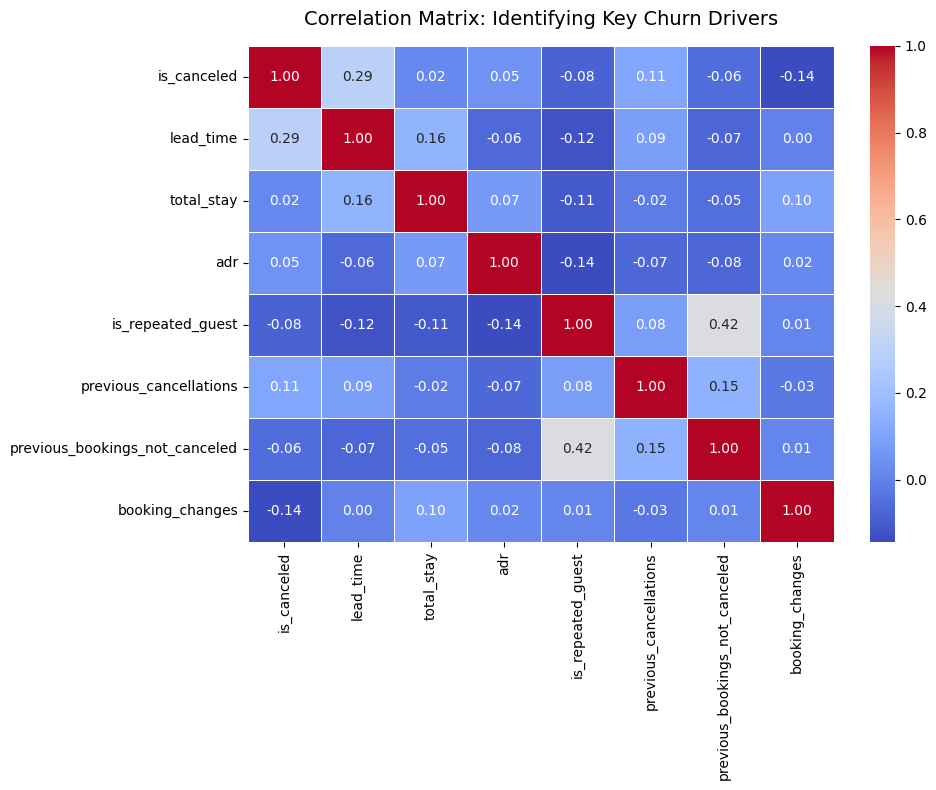

Week 2 Visualization generated and saved at: C:\Users\alaem\Downloads\churn-hotel-infotact\clean_data\week2\cancellation_correlation_matrix.png


<Figure size 640x480 with 0 Axes>

In [ ]:
#-----week2-----------------------------------------------------
# Selecting numerical variables for churn analysis
numeric_cols = [
    'is_canceled', 'lead_time', 'total_stay', 'adr',
    'is_repeated_guest', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes'
]
corr_matrix = df[numeric_cols].corr()
# Visualizing the Correlation Matrix using Seaborn and Matplotlib
# Plotting correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Identifying Key Churn Drivers", fontsize=14, pad=15)
plt.tight_layout()
plt.show()
# Saving the plot
plot_path = r"C:\Users\alaem\Downloads\churn-hotel-infotact\clean_data\week2\cancellation_correlation_matrix.png"
plt.savefig(plot_path)
print(f"Week 2 Visualization generated and saved at: {plot_path}")


## Statistical Significance & Exploratory Data Analysis (EDA) Findings

Below is the statistical evaluation of the generated correlation matrix, isolating the structural behavioral drivers behind booking cancellations (`is_canceled`).

### 1. Lead Time Effects (Pearson $r = 0.29$)
* **Statistical Finding**: `lead_time` exhibits the strongest positive linear correlation with booking cancellations ($r = 0.29$).
* **Business Insight**: As the number of days between the booking date and the arrival date increases, the probability of churn rises significantly. Guests with long lead times have a wider window to optimize their travel plans, search for competitive pricing, or encounter circumstantial changes, leading to higher cancellation rates.

### 2. Behavioral Churn Markers (Pearson $r = 0.11$)
* **Statistical Finding**: `previous_cancellations` shows a positive correlation ($r = 0.11$) with the current cancellation status.
* **Business Insight**: This represents a critical behavioral marker. Customers who have a historical record of canceling previous bookings are statistically more prone to canceling again, indicating a segment of volatile, low-loyalty consumer behavior.

### 3. Customer Engagement and Stability (Pearson $r = -0.14$)
* **Statistical Finding**: `booking_changes` possesses a noticeable negative correlation ($r = -0.14$) with `is_canceled`.
* **Business Insight**: The inverse relationship indicates that as a guest modifies their booking parameters (e.g., room configuration, dates, or special requests), their likelihood of canceling drops. Active modification signals strong customer commitment and operational investment in the stay, making them highly engaged and reliable guests.

### 4. Revenue & Pricing Impact (Pearson $r = 0.05$)
* **Statistical Finding**: The Average Daily Rate (`adr`) demonstrates a very weak, near-neutral positive correlation ($r = 0.05$) with cancellations when evaluated linearly.
* **Business Insight**: While pricing anomalies were mitigated during preprocessing, raw room rates alone do not heavily dictate cancellation patterns across the entire dataset. This implies that churn is more tightly coupled with scheduling flexibility and customer history than isolated pricing thresholds.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_excel('/content/drive/MyDrive/hotel_bookings.xlsx')

# 2. El khedma mta3 week 1 (Cleaning) bech nـندفو el data 9بل الـ modeling
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)
q_high = df['adr'].quantile(0.999)
df = df[(df['adr'] >= 0) & (df['adr'] < q_high)]
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

print("--- Data Cleaned and Loaded Successfully ---")
print(f"Dataset Shape: {df.shape}\n")

# 3. Nest3mlou el columns el numerical kahaw (Style débutant kima el bootcamp)
features_cols = [
    'lead_time', 'total_stay', 'adr', 'is_repeated_guest',
    'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes'
]

X = df[features_cols]
y = df['is_canceled']

# 4. Split l-data: 80% train w 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Data Splitting Done ---")
print(f"Train data size: {X_train.shape[0]} rows")
print(f"Test data size: {X_test.shape[0]} rows\n")

# 5. Model Initialization & Training
model = LogisticRegression(max_iter=1000)
print("Training the model... Please wait...")
model.fit(X_train, y_train)

# 6. Making Predictions & Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n================ EVALUATION ================")
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

--- Data Cleaned and Loaded Successfully ---
Dataset Shape: (119269, 33)

--- Data Splitting Done ---
Train data size: 95415 rows
Test data size: 23854 rows

Training the model... Please wait...

================ EVALUATION ================
Model Accuracy: 70.01%

Detailed Report:
              precision    recall  f1-score   support

           0       0.70      0.91      0.79     14949
           1       0.70      0.34      0.46      8905

    accuracy                           0.70     23854
   macro avg       0.70      0.63      0.63     23854
weighted avg       0.70      0.70      0.67     23854

